# Project 5B: Flow Matching from Scratch!

## Setup environment

In [1]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.5 MB/s eta 0:00:00


In [2]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [ ]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.net(x)
        # ===== end of code ====


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.pool = nn.AvgPool2d(2)
        self.conv = Conv(in_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.conv(self.pool(x))
        # ===== end of code ====



class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.up(x)
        # ===== end of code ====


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        # ===== your code here! ====

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return torch.flatten(x, start_dim=1)
        # ===== end of code ====



class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.out_channels = in_channels
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        B = x.size(0)
        return x.view(B, self.out_channels, 7, 7)
        # ===== end of code ====



class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.block = nn.Sequential(
            Conv(in_channels, out_channels),
            Conv(out_channels, out_channels)
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.block(x)
        # ===== end of code ====


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv_block = ConvBlock(in_channels, out_channels)
        self.down = DownConv(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        skip = self.conv_block(x)
        x_down = self.down(skip)
        return skip, x_down
        # ===== end of code ====



class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.up = UpConv(in_channels, out_channels)
        self.conv_block = ConvBlock(out_channels * 2, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor, skip) -> torch.Tensor:
        # ===== your code here! ====
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv_block(x)
        # ===== end of code ====

## Implementing Unconditional UNet

In [13]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====

        # down
        self.enc1 = ConvBlock(in_channels, num_hiddens)
        self.down1 = DownBlock(num_hiddens, num_hiddens)
        self.down2 = DownBlock(num_hiddens, num_hiddens * 2)

        # flattening
        self.flatten = Flatten()
        self.unflatten = Unflatten(num_hiddens * 2)

        # up
        self.up1 = UpBlock(num_hiddens * 2, num_hiddens * 2)
        self.up2 = UpBlock(num_hiddens * 2, num_hiddens)

        self.final = nn.Conv2d(num_hiddens, in_channels, kernel_size=1)

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====

        x1 = self.enc1(x)
        skip1, x2 = self.down1(x1)
        skip2, x3 = self.down2(x2)

        x = self.unflatten(self.flatten(x3))

        x = self.up1(x, skip2)
        x = self.up2(x, skip1)

        return self.final(x)

        # ===== end of code ====

# Part 1.2: Using the UNet to Train a Denoiser

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.75MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.15MB/s]


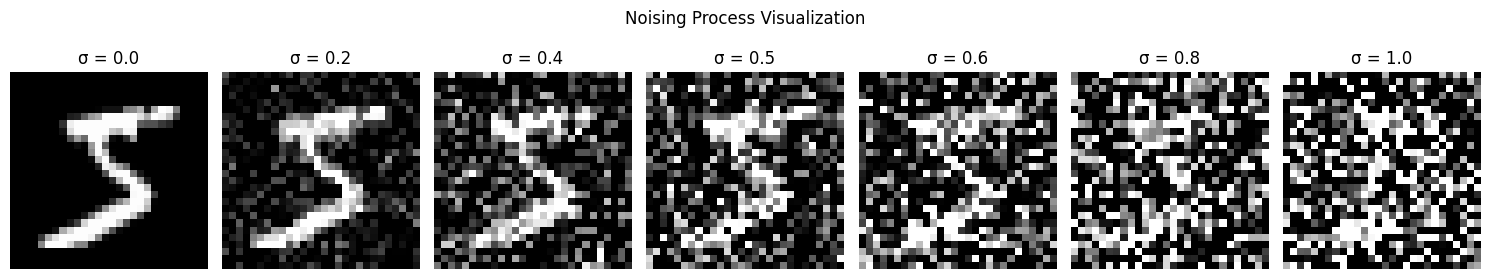

In [ ]:
# Visualize images at different noisy level
# ===== your code here! ====
sample_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
sample_image, _ = sample_dataset[0]  # Get first image
# noise levels
sigma_values = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(1, len(sigma_values), figsize=(15, 3))
for idx, sigma in enumerate(sigma_values):
    # generate gaussian noise
    noise = torch.randn_like(sample_image) * sigma
    noisy_image = sample_image + noise
    noisy_image = torch.clamp(noisy_image, 0, 1)

    axes[idx].imshow(noisy_image.squeeze(), cmap='gray')
    axes[idx].set_title(f'σ = {sigma}')
    axes[idx].axis('off')
plt.suptitle('Noising Process Visualization')
plt.tight_layout()
plt.show()
# ===== end of code ====

## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [ ]:
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 256
learning_rate = 1e-4
noise_level = 0.5
hidden_dim = 128
num_epochs = 5
# ===== end of code ====

In [ ]:
# Define your datasets and dataloaders
# ===== your code here! ====
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# ===== end of code ====

In [ ]:
# Define your model, optimizer, and loss
# ===== your code here! ====
model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
# ===== end of code ====

In [ ]:
def visualize_results(model, test_loader, epoch, noise_level):
    with torch.no_grad():
        # test images
        test_images, _ = next(iter(test_loader))
        test_images = test_images.to(device)

        noise = torch.randn_like(test_images) * noise_level
        noisy_test_images = test_images + noise
        denoised_images = model(noisy_test_images)

        num_samples = 3
        fig, axes = plt.subplots(num_samples, 3, figsize=(9, 9))

        for i in range(num_samples):
            # original
            axes[i, 0].imshow(test_images[i].cpu().squeeze(), cmap='gray')
            if i == 0:
                axes[i, 0].set_title('Input')
            axes[i, 0].axis('off')

            # noisy
            axes[i, 1].imshow(noisy_test_images[i].cpu().squeeze(), cmap='gray')
            if i == 0:
                axes[i, 1].set_title(f'Noisy (σ={noise_level})')
            axes[i, 1].axis('off')

            # denoised
            axes[i, 2].imshow(denoised_images[i].cpu().squeeze(), cmap='gray')
            if i == 0:
                axes[i, 2].set_title('Output')
            axes[i, 2].axis('off')

        plt.suptitle(f'Results on digits from the test set after epoch {epoch}')
        plt.tight_layout()
        plt.show()

100%|██████████| 235/235 [01:15<00:00,  3.13it/s]


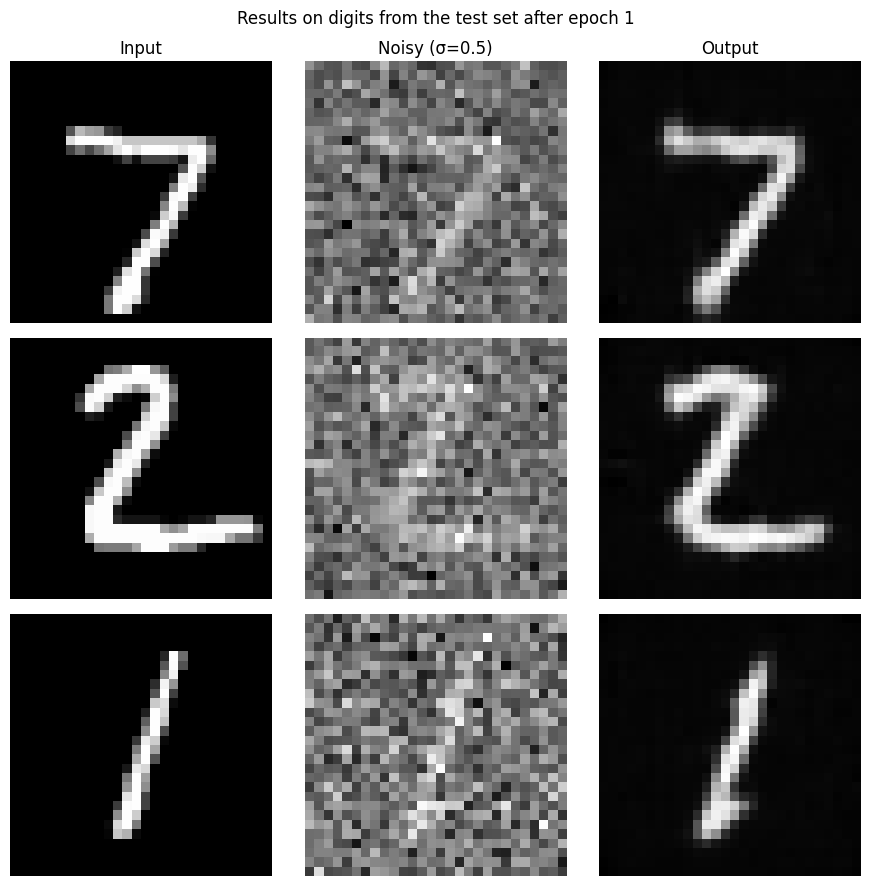

100%|██████████| 235/235 [01:17<00:00,  3.03it/s]


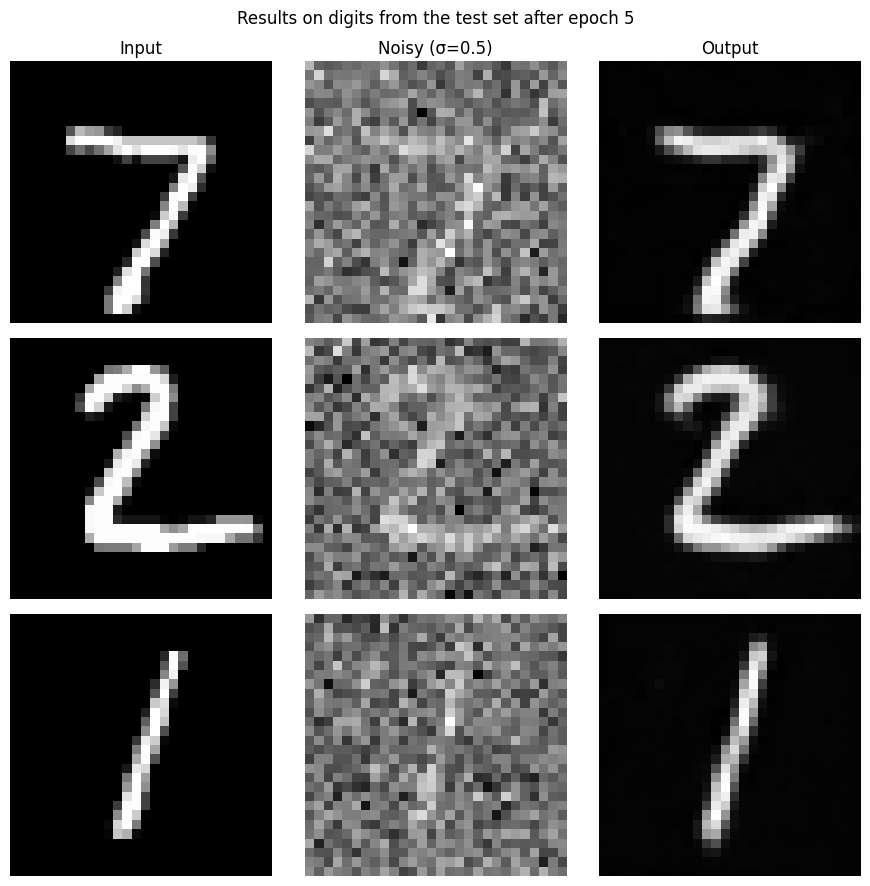

In [ ]:
# The training loops
train_losses = []
visualize = [1, 5]

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(tqdm(train_loader)):

        # ===== your code here! ====
        images = images.to(device)
        noise = torch.randn_like(images) * noise_level
        noisy_images = images + noise

        outputs = model(noisy_images)

        # ===== end of code ====

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    if (epoch + 1) in visualize:
        visualize_results(model, test_loader, epoch + 1, noise_level)

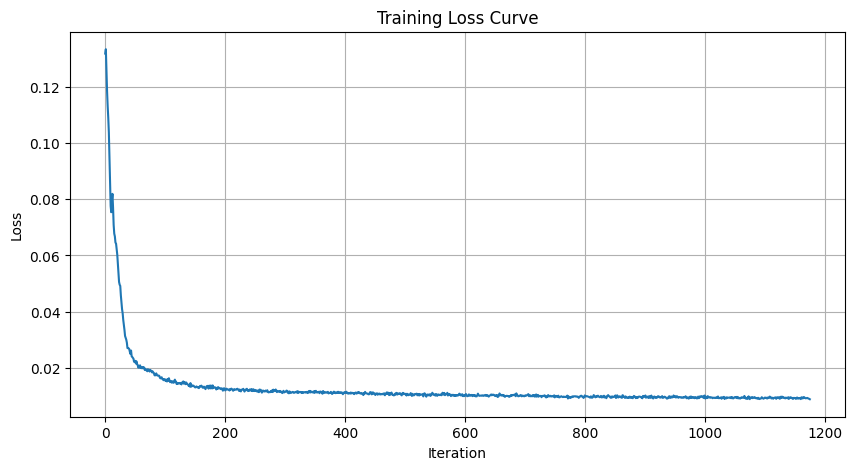

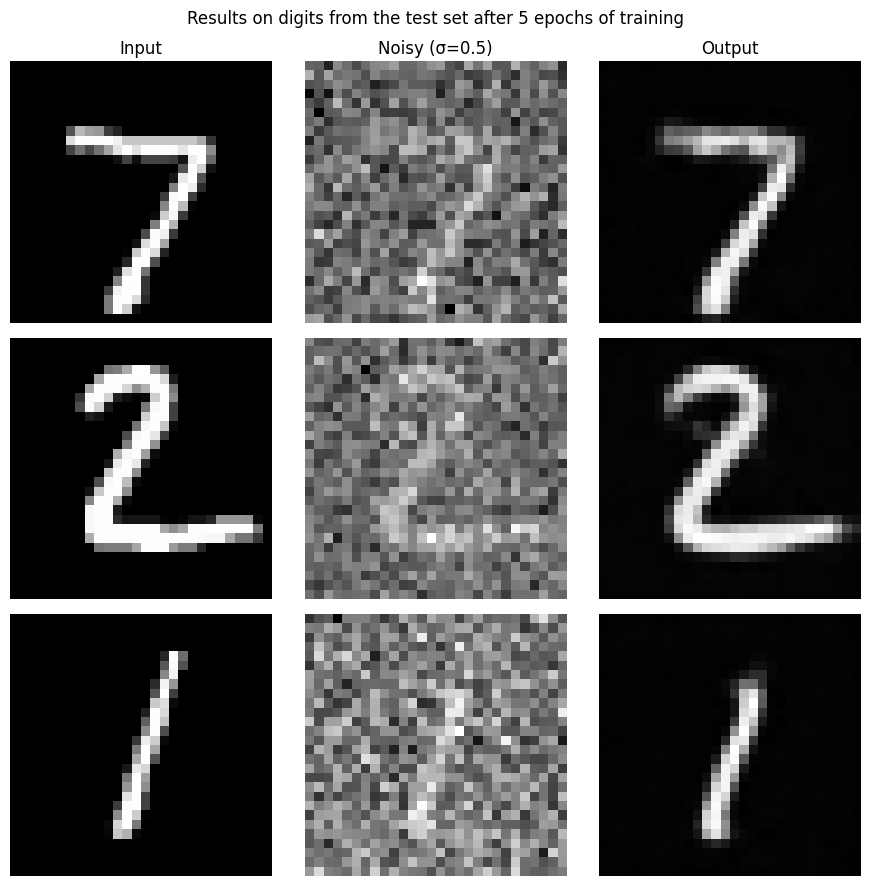

In [ ]:
# Visualize your training curve
# ===== your code here! ====
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()


# test results
model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)

    noise = torch.randn_like(test_images) * noise_level
    noisy_test_images = test_images + noise

    denoised_images = model(noisy_test_images)

    num_samples = 3
    fig, axes = plt.subplots(num_samples, 3, figsize=(9, 9))

    for i in range(num_samples):
        # original
        axes[i, 0].imshow(test_images[i].cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Input' if i == 0 else '')
        axes[i, 0].axis('off')

        # noisy
        axes[i, 1].imshow(noisy_test_images[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title(f'Noisy (σ={noise_level})' if i == 0 else '')
        axes[i, 1].axis('off')

        # denoised
        axes[i, 2].imshow(denoised_images[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Output' if i == 0 else '')
        axes[i, 2].axis('off')

    plt.suptitle(f'Results on digits from the test set after {num_epochs} epochs of training')
    plt.tight_layout()
    plt.show()
# ===== end of code ====

## Part 1.2.2: Out-of-Distribution Testing

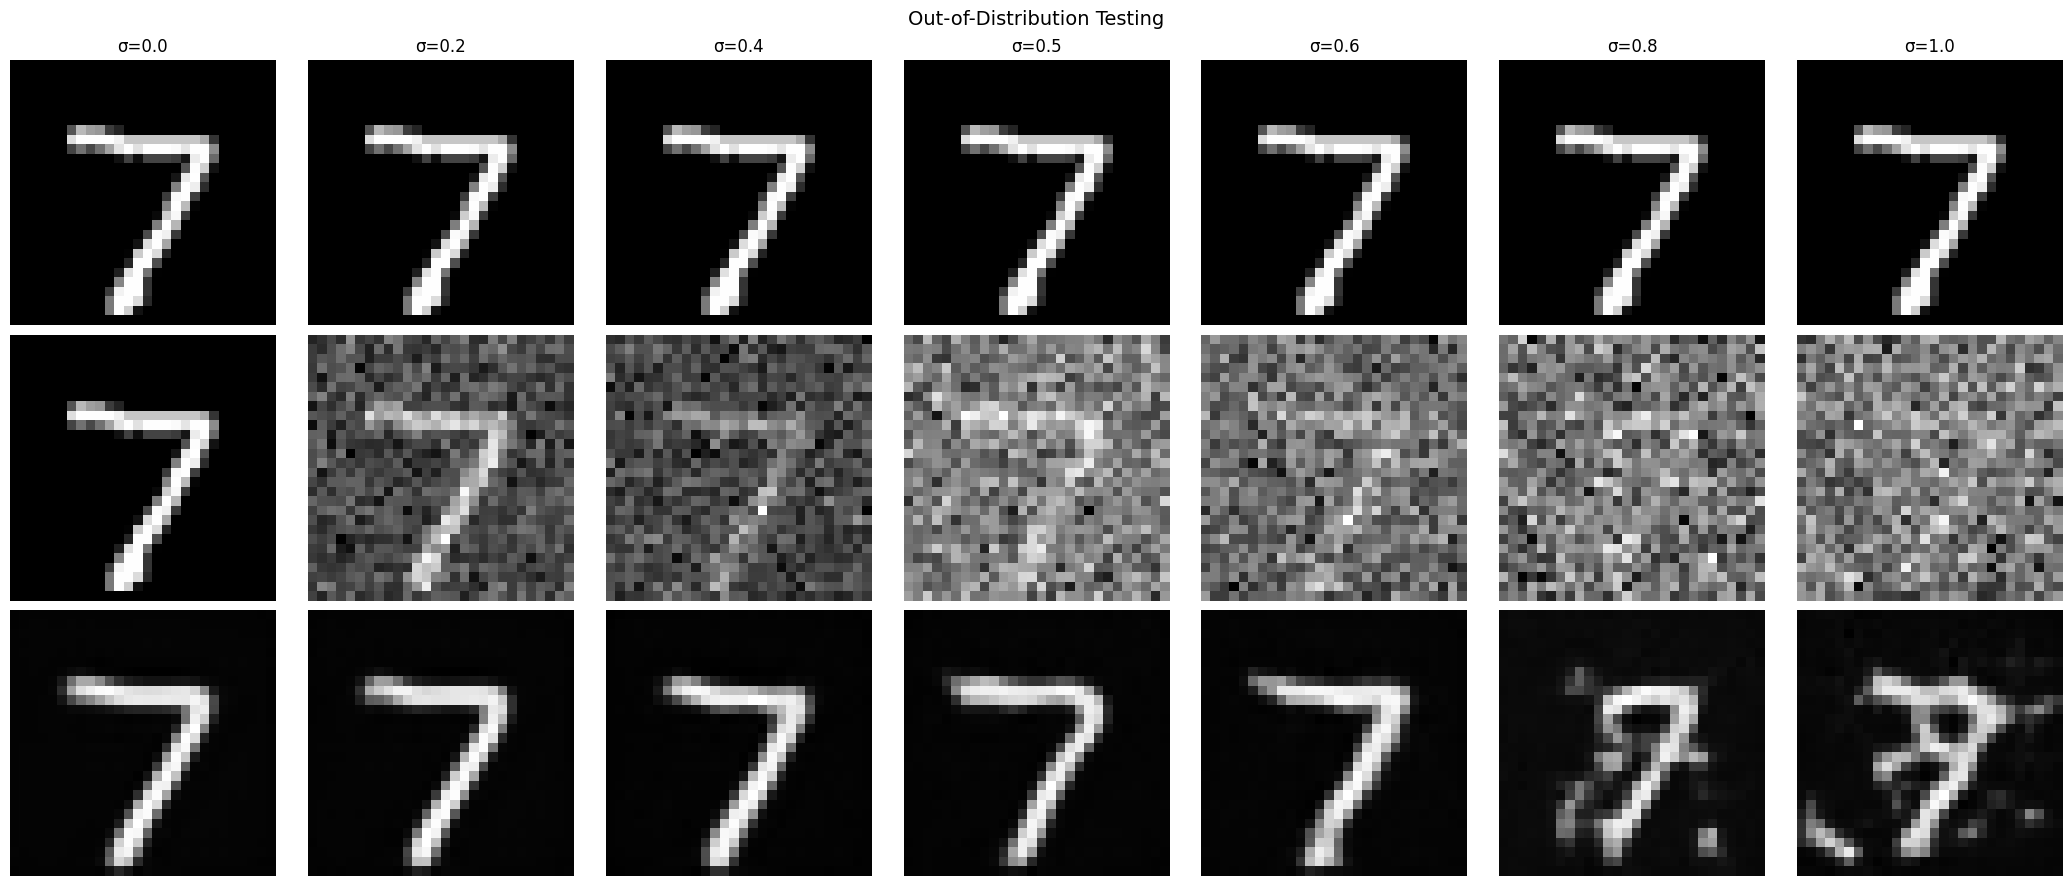

In [ ]:
# Visualize OOD testing
# ===== your code here! ====
sigma_values = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

model.eval()
with torch.no_grad():
  test_images, _ = next(iter(test_loader))
  test_image = test_images[0:1].to(device)

  fig, axes = plt.subplots(3, len(sigma_values), figsize=(len(sigma_values) * 3, 9))

  for idx, sigma in enumerate(sigma_values):
    # noise
    noise = torch.randn_like(test_image) * sigma
    noisy_image = test_image + noise

    # denoise
    denoised_image = model(noisy_image)

    # orignal
    axes[0, idx].imshow(test_image.cpu().squeeze(), cmap='gray')
    axes[0, idx].set_title(f'σ={sigma}')
    if idx == 0:
      axes[0, idx].set_ylabel('Input', fontsize=12)
    axes[0, idx].axis('off')

    # noisy
    axes[1, idx].imshow(noisy_image.cpu().squeeze(), cmap='gray')
    if idx == 0:
      axes[1, idx].set_ylabel('Noisy', fontsize=12)
    axes[1, idx].axis('off')

    # denoised
    axes[2, idx].imshow(denoised_image.cpu().squeeze(), cmap='gray')
    if idx == 0:
      axes[2, idx].set_ylabel('Output', fontsize=12)
    axes[2, idx].axis('off')

  plt.suptitle('Out-of-Distribution Testing', fontsize=14)
  plt.tight_layout()
  plt.show()
# ===== end of code ====

## Part 1.2.3 Denoising Pure Noise

Epoch 1/5: 100%|██████████| 235/235 [01:12<00:00,  3.23it/s]


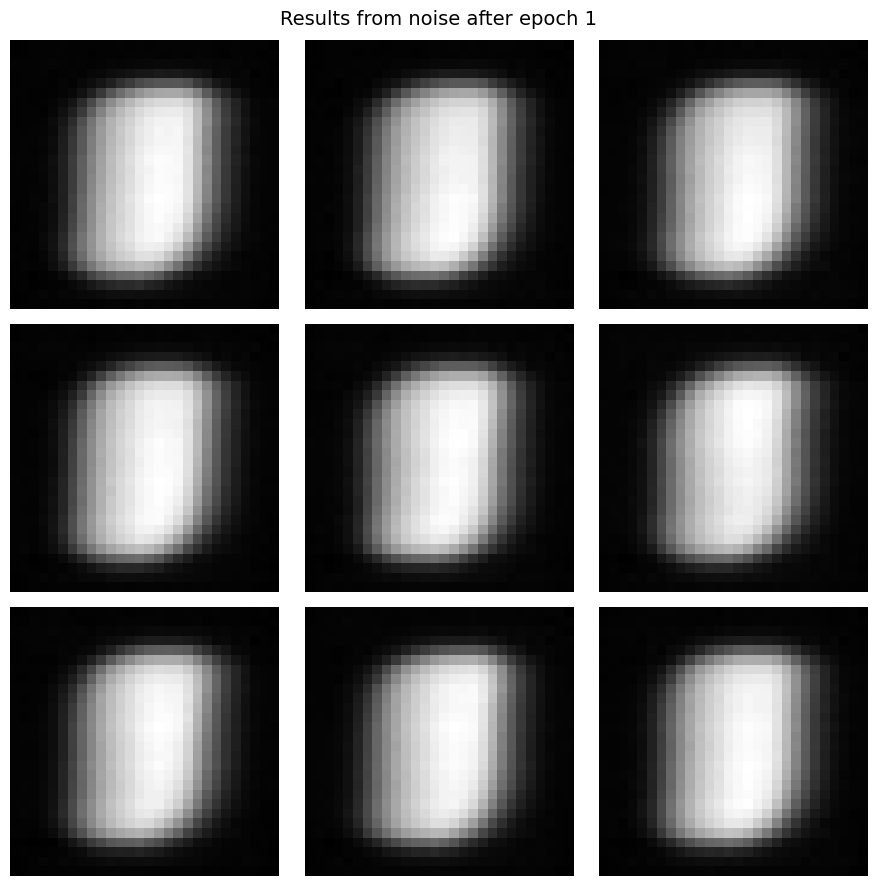

Epoch 5/5: 100%|██████████| 235/235 [01:14<00:00,  3.14it/s]


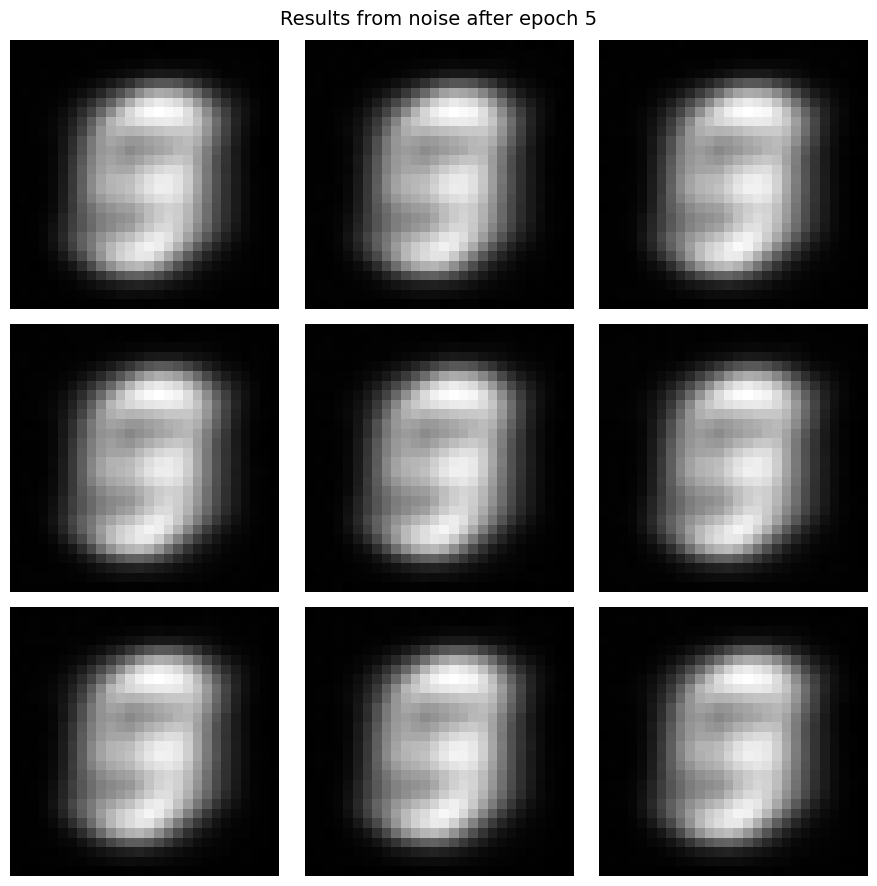

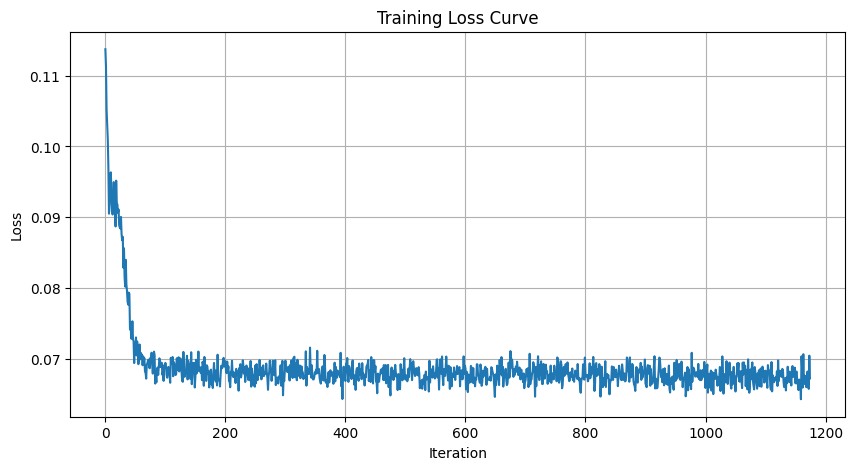

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
noise = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer_pure_noise = torch.optim.Adam(noise.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

train_loss_pure_noise = []
visualize = [1, 5]
num_epochs = 5 # 2

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')):
        images = images.to(device)

        pure_noise = torch.randn_like(images)
        outputs = noise(pure_noise)

        loss = criterion(outputs, images)
        optimizer_pure_noise.zero_grad()
        loss.backward()
        optimizer_pure_noise.step()
        train_loss_pure_noise.append(loss.item())

    if (epoch + 1) in visualize:
        noise.eval()
        with torch.no_grad():
            test_noise = torch.randn(9, 1, 28, 28).to(device)
            generated_images = noise(test_noise)

            fig, axes = plt.subplots(3, 3, figsize=(9, 9))
            for idx in range(9):
                row = idx // 3
                col = idx % 3
                axes[row, col].imshow(generated_images[idx].cpu().squeeze(), cmap='gray')
                axes[row, col].axis('off')

            plt.suptitle(f'Results from noise after epoch {epoch + 1}', fontsize=14)
            plt.tight_layout()
            plt.show()
        noise.train()

# visualize
plt.figure(figsize=(10, 5))
plt.plot(train_loss_pure_noise)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

# ===== end of code ====

Patterns Observed: When training using pure noise, the denoiser learns to minimize the average squared distance to all training examples, leading to a blurred, average of all the digits. This is evident in epoch 1 but becomes clearer in epoch 5 and shows the outline of all digits overlayed on top of each other.

# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [ ]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.fc1 = nn.Linear(in_channels, out_channels)
        self.gelu = nn.GELU()
        self.fc2 = nn.Linear(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.fc2(x)
        x = self.gelu(x)
        return x
        # ===== end of code ====


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens

        # time embeds
        self.fc1_t = FCBlock(1, D)
        self.fc2_t = FCBlock(1, D * 2)

        self.enc1 = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, D * 2)

        self.flatten = Flatten()
        self.unflatten = Unflatten(D * 2)

        self.up1 = UpBlock(D * 2, D * 2)
        self.up2 = UpBlock(D * 2, D)

        self.final = nn.Conv2d(D, in_channels, kernel_size=1)
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        t = t.view(-1, 1) 

        # time embeds
        t1 = self.fc1_t(t)
        t2 = self.fc2_t(t)

        x1 = self.enc1(x)
        skip1, x2 = self.down1(x1)
        skip2, x3 = self.down2(x2)

        x_flat = self.flatten(x3)
        x = self.unflatten(x_flat)

        x = x * t2.view(-1, t2.shape[1], 1, 1)
        x = self.up1(x, skip2)
        x = x * t2.view(-1, t2.shape[1], 1, 1)
        x = self.up2(x, skip1)
        x = x * t1.view(-1, t1.shape[1], 1, 1)

        return self.final(x)
        # ===== end of code ====

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [ ]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    N = x_1.shape[0]
    t = torch.rand(N, device=x_1.device)

    # sample noise x_0
    x_0 = torch.randn_like(x_1)

    # x_t = (1 - t)x_0 + t*x_1
    t_expanded = t.view(N, 1, 1, 1)
    x_t = (1 - t_expanded) * x_0 + t_expanded * x_1

    u_pred = unet(x_t, t)
    u_true = x_1 - x_0

    loss = nn.functional.mse_loss(u_pred, u_true)

    return loss
    # ===== end of code ====

In [ ]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # ===== your code here! ====
    torch.manual_seed(seed)
    device = next(unet.parameters()).device
    H, W = img_wh
    x = torch.randn(1, 1, H, W, device=device)

    dt = 1.0 / num_ts

    for i in range(num_ts):
        t = torch.tensor([i / num_ts], device=device)
        u = unet(x, t)
        x = x + dt * u

    return x
    # ===== end of code ====

In [6]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Part 2.2: Training the Time-conditioned UNet

Epoch 1/10: 100%|██████████| 469/469 [01:17<00:00,  6.05it/s]


Epoch [1/10], Average Loss: 0.4296, LR: 0.000900


Epoch 2/10: 100%|██████████| 469/469 [01:16<00:00,  6.11it/s]


Epoch [2/10], Average Loss: 0.1238, LR: 0.000810


Epoch 3/10: 100%|██████████| 469/469 [01:16<00:00,  6.12it/s]


...

Epoch [8/10], Average Loss: 0.0966, LR: 0.000430


Epoch 9/10: 100%|██████████| 469/469 [01:16<00:00,  6.12it/s]


Epoch [9/10], Average Loss: 0.0961, LR: 0.000387


Epoch 10/10: 100%|██████████| 469/469 [01:16<00:00,  6.11it/s]


Epoch [10/10], Average Loss: 0.0945, LR: 0.000349


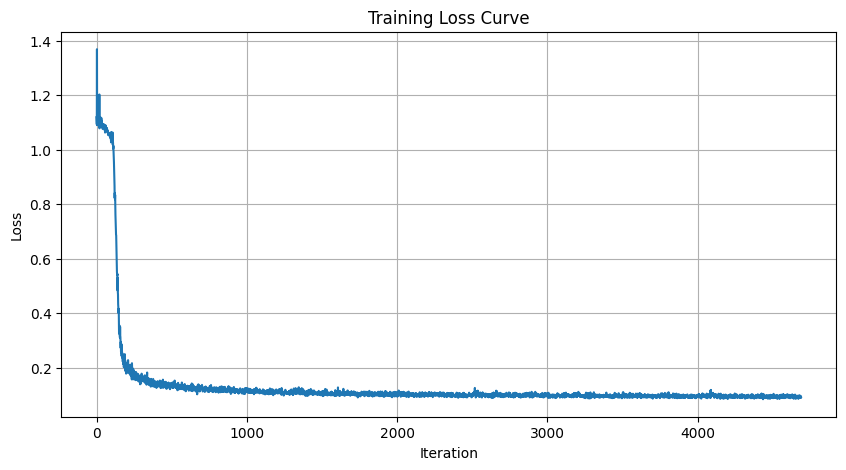

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# hyperparameters
batch_size = 128
learning_rate = 1e-3
hidden_dim = 128
num_epochs = 10=
num_ts = 50

# load data
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# model + optimzier
time_unet = TimeConditionalUNet(in_channels=1, num_classes=10, num_hiddens=hidden_dim).to(device)
flow_model = TimeConditionalFM(unet=time_unet, num_ts=num_ts, img_hw=(28, 28))

optimizer = torch.optim.Adam(time_unet.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

# train
train_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0

    for i, (images, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')):
        images = images.to(device)
        loss = flow_model(images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        epoch_loss += loss.item()

    scheduler.step()

    avg_epoch_loss = epoch_loss / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_epoch_loss:.4f}, LR: {current_lr:.6f}')

# visualize
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

# ===== end of code ====

# Part 2.3: Sampling from the Time-conditioned UNet

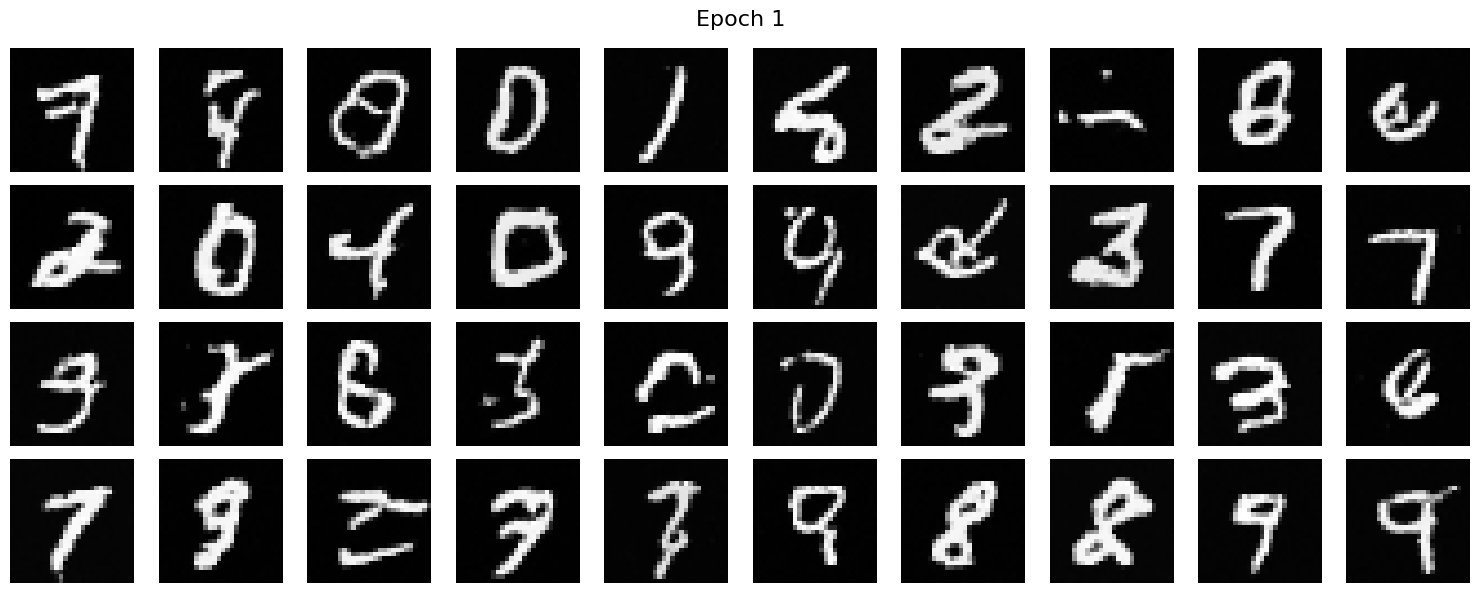

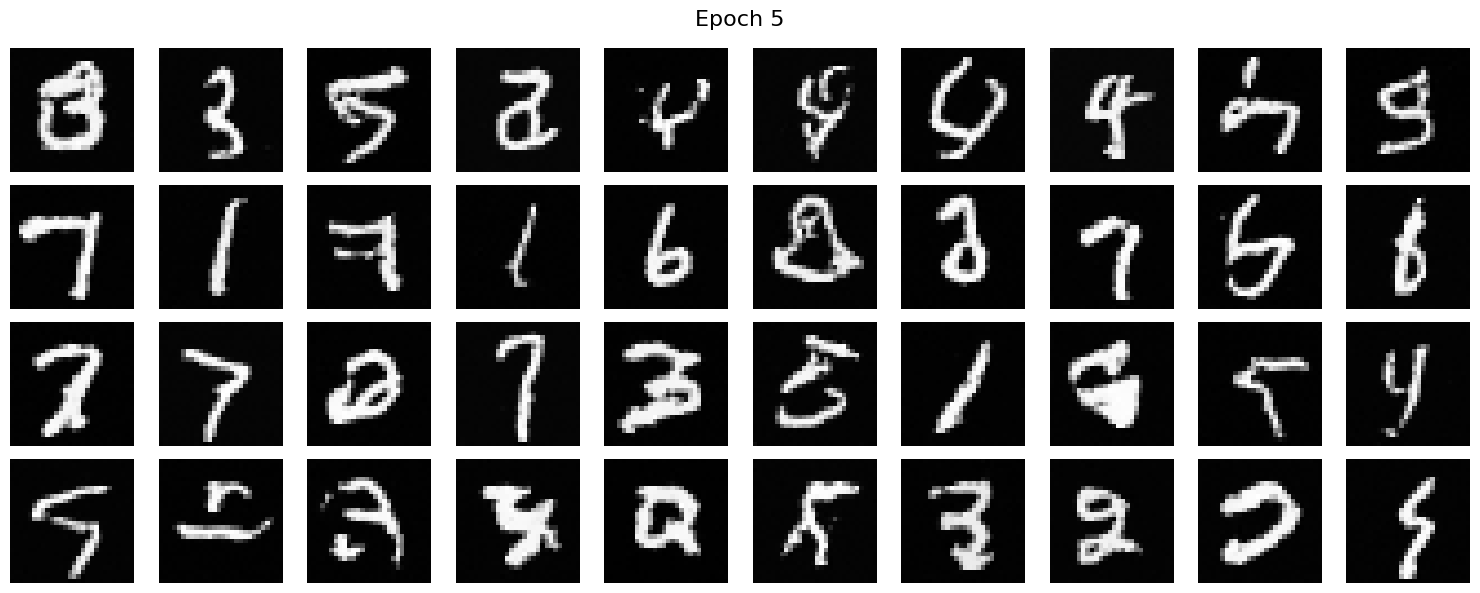

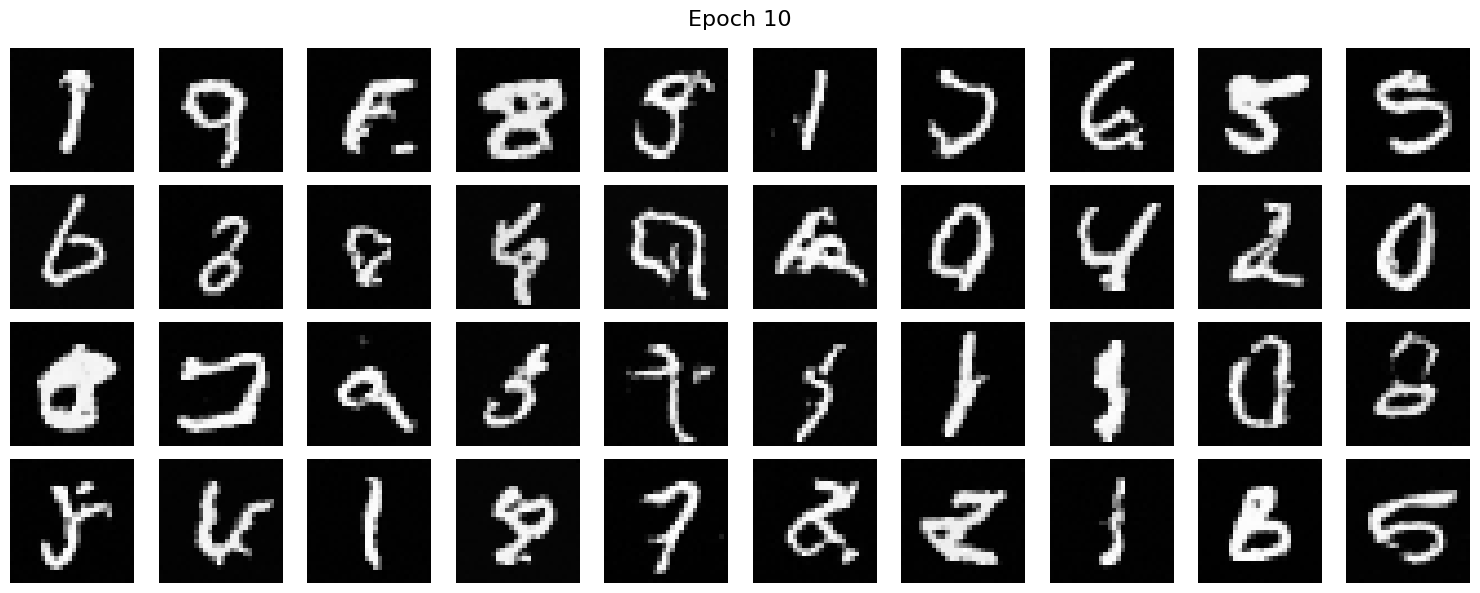

In [ ]:
# Sampling from the UNet
# ===== your code here! ====

epochs_to_sample = [1, 5, 10]
for epoch_num in epochs_to_sample:
    samples = []
    for seed in range(40):
        sample = flow_model.sample(img_wh=(28, 28), seed=seed + epoch_num * 100)
        samples.append(sample.cpu().squeeze())

    fig, axes = plt.subplots(4, 10, figsize=(15, 6))
    for idx in range(40):
        row = idx // 10
        col = idx % 10
        axes[row, col].imshow(samples[idx], cmap='gray')
        axes[row, col].axis('off')

    plt.suptitle(f'Epoch {epoch_num}', fontsize=16)
    plt.tight_layout()
    plt.show()

# ===== end of code ====

# Part 2.4: Implementing a Class-conditioned UNet

In [ ]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens
        self.num_classes = num_classes
        # time embed
        self.fc1_t = FCBlock(1, D)
        self.fc2_t = FCBlock(1, D * 2)

        # class embed
        self.fc1_c = FCBlock(num_classes, D)
        self.fc2_c = FCBlock(num_classes, D * 2)

        self.enc1 = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, D * 2)

        self.flatten = Flatten()
        self.unflatten = Unflatten(D * 2)

        self.up1 = UpBlock(D * 2, D * 2)
        self.up2 = UpBlock(D * 2, D)

        self.final = nn.Conv2d(D, in_channels, kernel_size=1)
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        N = x.shape[0]

        # create one-hot vector
        c_onehot = torch.nn.functional.one_hot(c, num_classes=self.num_classes).float()

        if mask is not None:
            c_onehot = c_onehot * mask.view(-1, 1)

        t = t.view(-1, 1)
        t1 = self.fc1_t(t)
        t2 = self.fc2_t(t)

        c1 = self.fc1_c(c_onehot)
        c2 = self.fc2_c(c_onehot)

        x1 = self.enc1(x)
        skip1, x2 = self.down1(x1)
        skip2, x3 = self.down2(x2)

        x = self.unflatten(self.flatten(x3))
        x = x * (c2.view(N, -1, 1, 1) + t2.view(N, -1, 1, 1))
        x = self.up1(x, skip2)
        x = x * (c2.view(N, -1, 1, 1) + t2.view(N, -1, 1, 1))
        x = self.up2(x, skip1)
        x = x * (c1.view(N, -1, 1, 1) + t1.view(N, -1, 1, 1))

        return self.final(x)
        # ===== end of code ====

In [ ]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    N = x_1.shape[0]
    device = x_1.device
    t = torch.rand(N, device=device)

    x_0 = torch.randn_like(x_1)
    t_expanded = t.view(N, 1, 1, 1)

    x_t = (1 - t_expanded) * x_0 + t_expanded * x_1
    mask = (torch.rand(N, device=device) > p_uncond).float()

    u_pred = unet(x_t, c, t, mask=mask)
    u_true = x_1 - x_0

    # mse
    return nn.functional.mse_loss(u_pred, u_true)
    # ===== end of code ====

In [ ]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # ===== your code here! ====
    torch.manual_seed(seed)

    device = next(unet.parameters()).device
    N = c.shape[0]
    H, W = img_wh
    # noise
    x = torch.randn(N, 1, H, W, device=device)
    c = c.to(device)

    # step size
    dt = 1.0 / num_ts
    for i in range(num_ts):
        t = torch.full((N,), i / num_ts, device=device)
        # class
        mask_cond = torch.ones(N, device=device)
        u_cond = unet(x, c, t, mask=mask_cond)

        # without class
        mask_uncond = torch.zeros(N, device=device)
        u_uncond = unet(x, c, t, mask=mask_uncond)
        u = u_uncond + guidance_scale * (u_cond - u_uncond)

        x = x + dt * u

    return x
    # ===== end of code ====

In [10]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

Epoch 1/10: 100%|██████████| 469/469 [01:18<00:00,  5.98it/s]


Epoch 1/10, Average Loss: 0.4848, LR: 0.000900


Epoch 2/10: 100%|██████████| 469/469 [01:18<00:00,  5.96it/s]


Epoch 2/10, Average Loss: 0.1078, LR: 0.000810


Epoch 3/10: 100%|██████████| 469/469 [01:18<00:00,  6.00it/s]


...

Epoch 8/10, Average Loss: 0.0873, LR: 0.000430


Epoch 9/10: 100%|██████████| 469/469 [01:18<00:00,  5.99it/s]


Epoch 9/10, Average Loss: 0.0866, LR: 0.000387


Epoch 10/10: 100%|██████████| 469/469 [01:18<00:00,  5.96it/s]


Epoch 10/10, Average Loss: 0.0855, LR: 0.000349


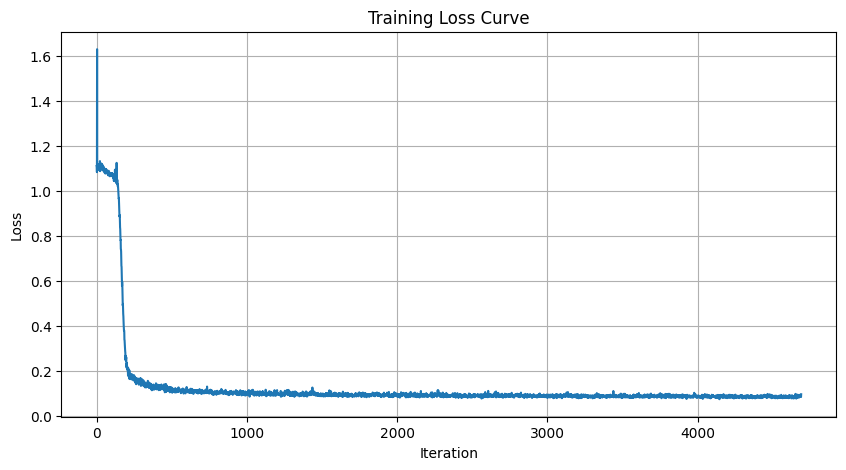

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# hyperparameters
batch_size = 128
learning_rate = 1e-3
hidden_dim = 128
num_classes = 10
num_epochs = 10
num_ts = 300 
p_uncond = 0.1

# load data
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# model + optimizer
class_unet = ClassConditionalUNet(in_channels=1, num_classes=num_classes, num_hiddens=hidden_dim).to(device)
class_flow_model = ClassConditionalFM(unet=class_unet, num_ts=num_ts, p_uncond=p_uncond)
optimizer = torch.optim.Adam(class_unet.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

# train
train_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0

    for i, (images, labels) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')):
        images = images.to(device)
        labels = labels.to(device)
        loss = class_flow_model(images, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        epoch_loss += loss.item()
    scheduler.step()

    avg_epoch_loss = epoch_loss / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_epoch_loss:.4f}, LR: {current_lr:.6f}')

# visualize
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()
# ===== end of code ====

# Part 2.6: Sampling from the Class-conditioned UNet

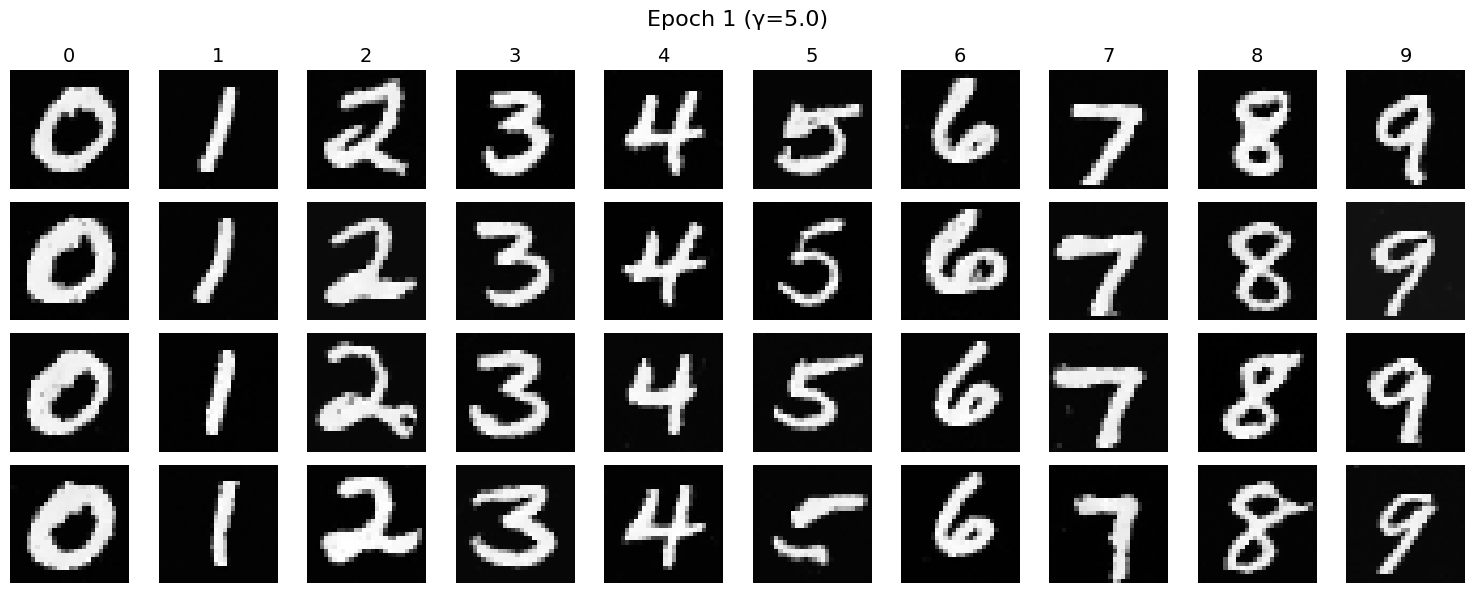

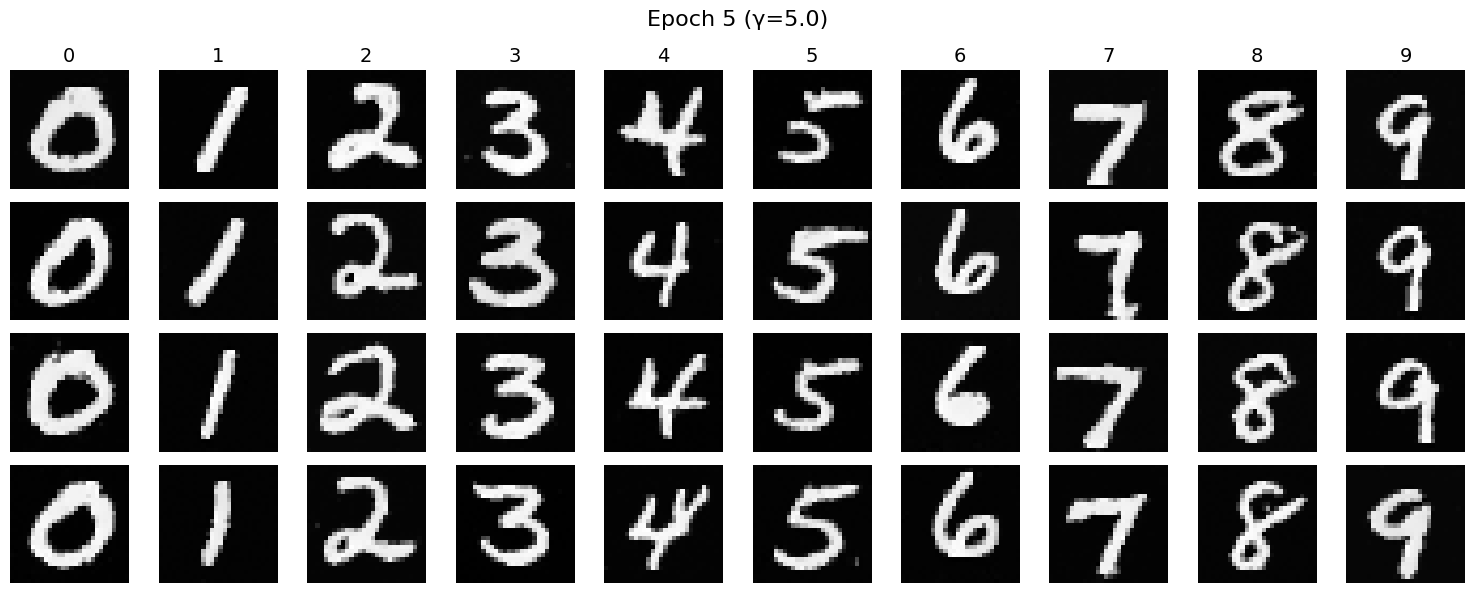

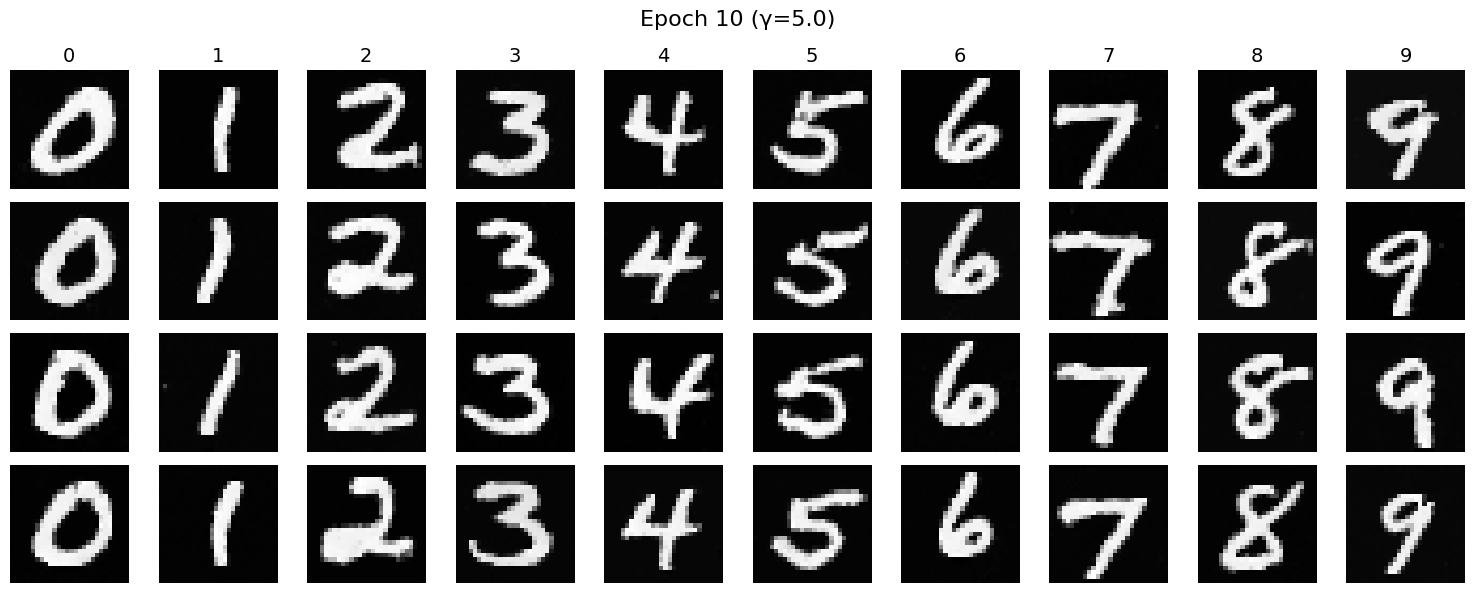

In [ ]:
# Sampling from the UNet
# ===== your code here! ====
epochs_to_sample = [1, 5, 10]
guidance_scale = 5.0

for epoch_num in epochs_to_sample:

    # 4 images per digit = 40 total
    samples = []

    for digit in range(10):
        for instance in range(4):
            c = torch.tensor([digit], dtype=torch.long)
            seed = epoch_num * 1000 + digit * 10 + instance
            sample = class_flow_model.sample(
                c=c,
                img_wh=(28, 28),
                guidance_scale=guidance_scale,
                seed=seed
            )
            samples.append(sample.cpu().squeeze())

    fig, axes = plt.subplots(4, 10, figsize=(15, 6))

    for idx in range(40):
        row = idx % 4
        col = idx // 4
        axes[row, col].imshow(samples[idx], cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(str(col), fontsize=14)

    plt.suptitle(f'Epoch {epoch_num} (γ={guidance_scale})', fontsize=16)
    plt.tight_layout()
    plt.show()
# ===== end of code ====

Epoch 1/10: 100%|██████████| 469/469 [01:13<00:00,  6.37it/s]


Epoch 1/10, Average Loss: 0.2197


Epoch 2/10: 100%|██████████| 469/469 [01:16<00:00,  6.14it/s]


Epoch 2/10, Average Loss: 0.1089


Epoch 3/10: 100%|██████████| 469/469 [01:16<00:00,  6.12it/s]


...

Epoch 8/10, Average Loss: 0.0873


Epoch 9/10: 100%|██████████| 469/469 [01:16<00:00,  6.12it/s]


Epoch 9/10, Average Loss: 0.0866


Epoch 10/10: 100%|██████████| 469/469 [01:16<00:00,  6.12it/s]


Epoch 10/10, Average Loss: 0.0861


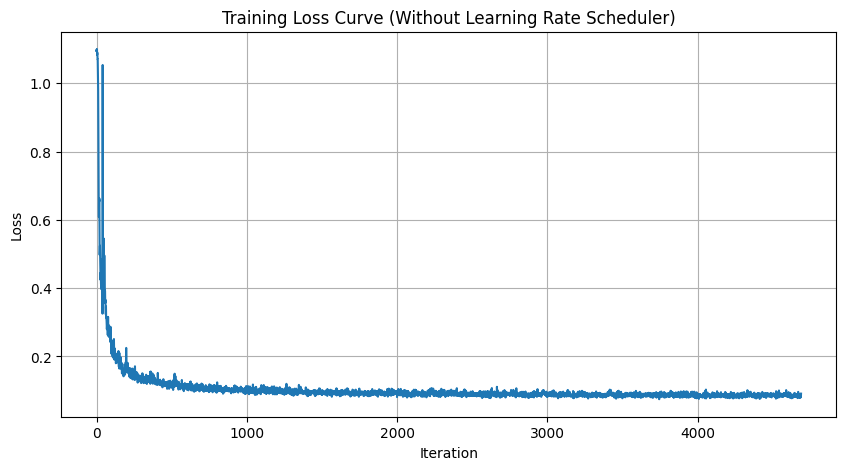

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# hyperparameters
batch_size = 128
learning_rate = 5e-4
hidden_dim = 128
num_classes = 10
num_epochs = 10
num_ts = 300
p_uncond = 0.1

# load data
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# model
class_unet_no_sched = ClassConditionalUNet(in_channels=1, num_classes=num_classes, num_hiddens=hidden_dim).to(device)
class_flow_model_no_sched = ClassConditionalFM(unet=class_unet_no_sched, num_ts=num_ts, p_uncond=p_uncond)
# use weight decay
optimizer = torch.optim.AdamW(
    class_unet_no_sched.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

# train
train_losses_no_sched = []
for epoch in range(num_epochs):
    epoch_loss = 0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
        images = images.to(device)
        labels = labels.to(device)
        loss = class_flow_model_no_sched(images, labels)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(class_unet_no_sched.parameters(), max_norm=1.0)

        optimizer.step()

        train_losses_no_sched.append(loss.item())
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_epoch_loss:.4f}')

# visualize
plt.figure(figsize=(10, 5))
plt.plot(train_losses_no_sched)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve (Without Learning Rate Scheduler)')
plt.grid(True)
plt.show()


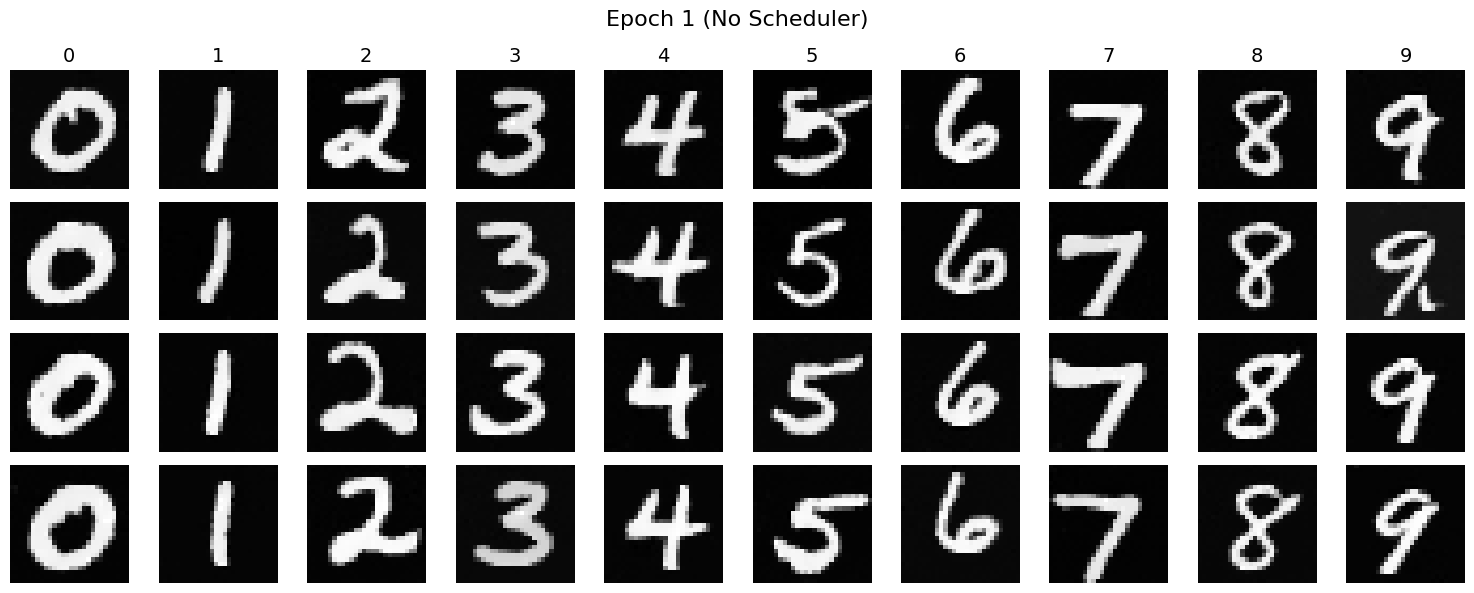

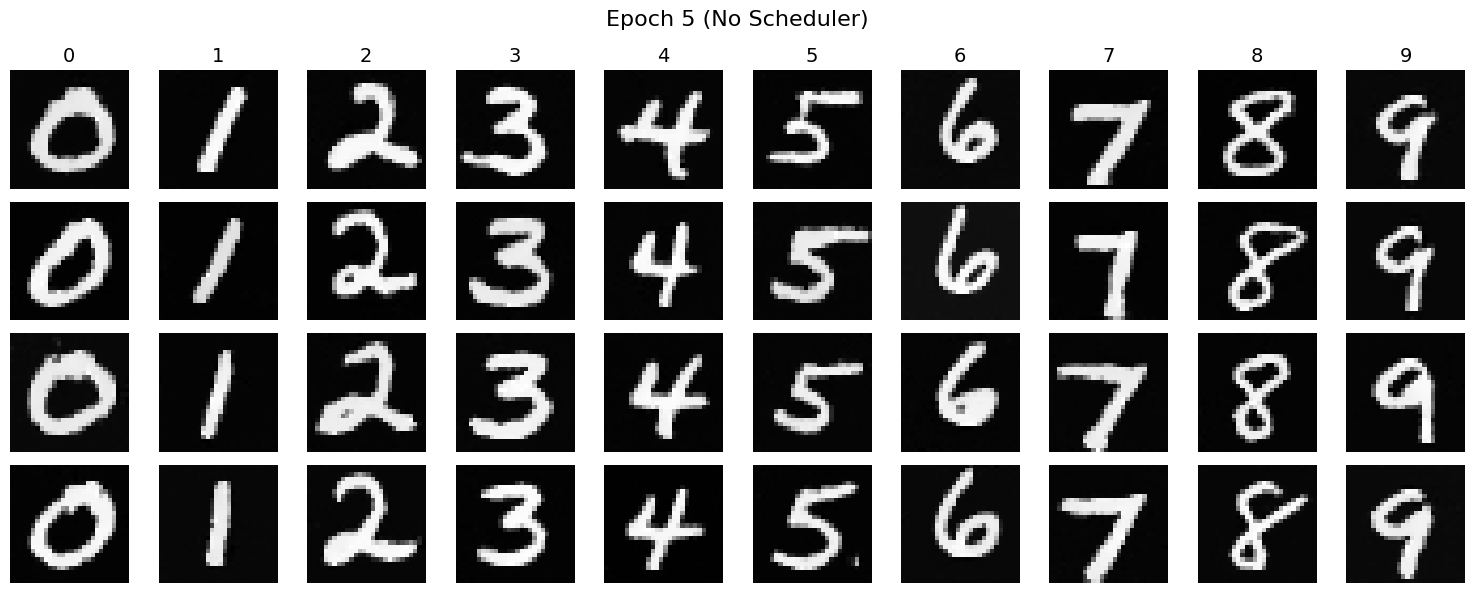

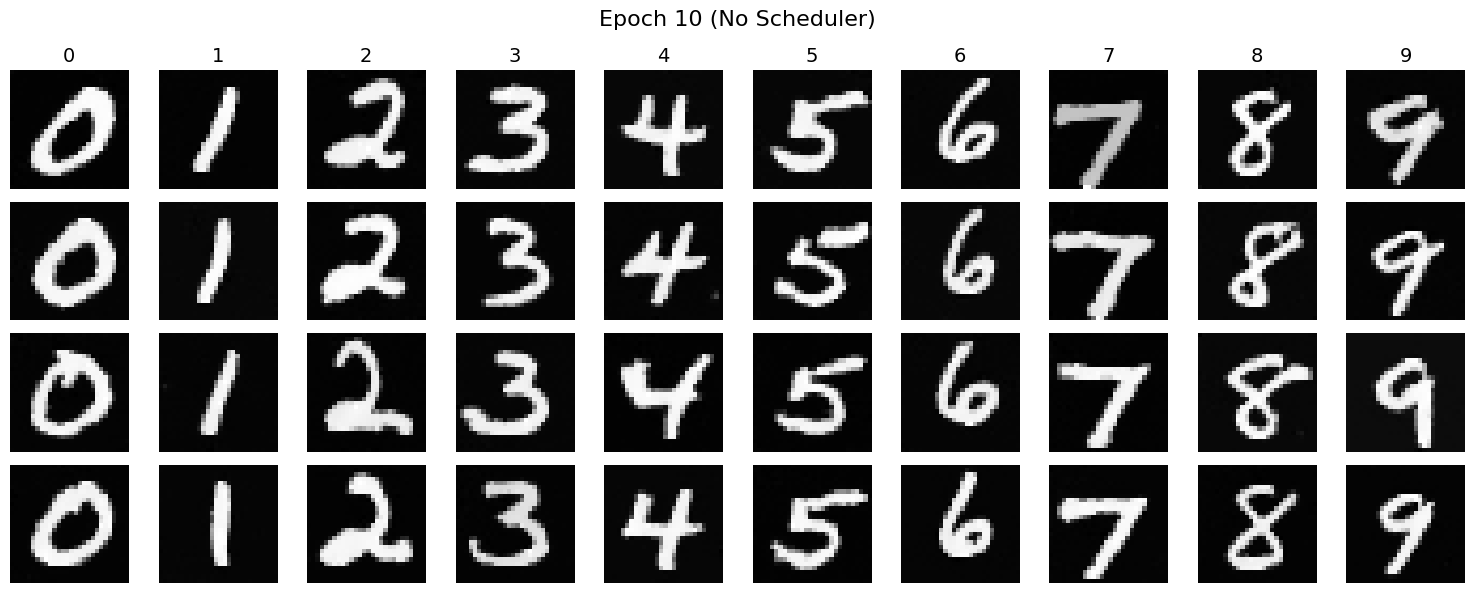

In [19]:
for epoch_num in [1, 5, 10]:
    samples = []

    for digit in range(10):
        for instance in range(4):
            c = torch.tensor([digit], dtype=torch.long)
            seed = epoch_num * 1000 + digit * 10 + instance
            sample = class_flow_model_no_sched.sample(
                c=c,
                img_wh=(28, 28),
                guidance_scale=5.0,
                seed=seed
            )
            samples.append(sample.cpu().squeeze())

    fig, axes = plt.subplots(4, 10, figsize=(15, 6))

    for idx in range(40):
        row = idx % 4
        col = idx // 4
        axes[row, col].imshow(samples[idx], cmap='gray')
        axes[row, col].axis('off')

        if row == 0:
            axes[row, col].set_title(str(col), fontsize=14)

    plt.suptitle(f'Epoch {epoch_num} (No Scheduler)', fontsize=16)
    plt.tight_layout()
    plt.show()